# Анализ тональности отзывов о фильмах

In [3]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

root_path = r"C:\Users\user\Desktop\dataset"

# Маппинг папок на тональность
folder_to_label = {
    'neg': 'Bad',
    'neu': 'Neutral',
    'pos': 'Good'
}

data = []

for folder_name, label in folder_to_label.items():
    folder_path = os.path.join(root_path, folder_name)

    if not os.path.exists(folder_path):
        print(f"⚠️ Предупреждение: папка {folder_path} не найдена")
        continue

    # glob быстрее и надёжнее, чем os.listdir + ручная фильтрация
    txt_files = glob.glob(os.path.join(folder_path, "*.txt"))

    for file_path in txt_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read().strip()
        except UnicodeDecodeError:
            # На случай файлов в другой кодировке (cp1251 и т.п.)
            with open(file_path, 'r', encoding='cp1251', errors='ignore') as f:
                text = f.read().strip()

        if not text:
            continue

        data.append({
            'file_name': os.path.basename(file_path),
            'folder': folder_name,
            'content': text,
            'grade3': label
        })

df = pd.DataFrame(data)

# Удаляем возможные полные дубликаты отзывов
before = len(df)
df = df.drop_duplicates(subset='content').reset_index(drop=True)
print(f"🧹 Удалено дубликатов: {before - len(df)}")

print(f"✅ Загружено {len(df)} отзывов")
print("\n📊 Распределение по классам:")
print(df['grade3'].value_counts())
print("\n📊 Распределение по папкам:")
print(df['folder'].value_counts())

print("\n📝 Пример отзыва:")
print(df['content'].iloc[0][:300] + "...")

🧹 Удалено дубликатов: 96
✅ Загружено 131573 отзывов

📊 Распределение по классам:
grade3
Good       87091
Neutral    24678
Bad        19804
Name: count, dtype: int64

📊 Распределение по папкам:
folder
pos    87091
neu    24678
neg    19804
Name: count, dtype: int64

📝 Пример отзыва:
В 2003-ем году под руководством малоизвестного режиссёра Кларка Джонсона студия 'Columbia Pictures' решилась на полнометражную экранизацию сериала 'Спецназ' (в оригинале 'S.W.A.T.) с Сэмюелем Л. Джексоном и Колином Фарреллом в главных ролях. Лента собрала неплохую кассу, но отзывы критиков оказались...


## Разведочный анализ данных (EDA)

C:\Users\user\AppData\Local\Temp\ipykernel_3336\2827904426.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='grade3', data=df, order=order, ax=axes[0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_3336\2827904426.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='grade3', y='text_length', data=df, order=order, ax=axes[1], palette='Set2')


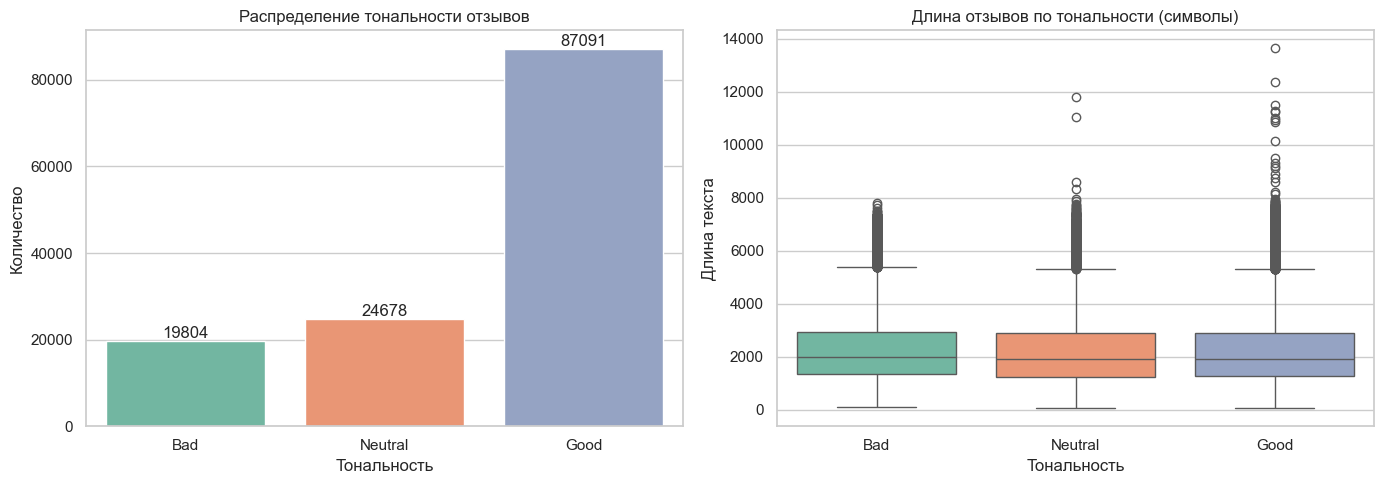

grade3                      Bad          Good       Neutral
text_length count  19804.000000  87091.000000  24678.000000
            mean    2302.496314   2264.697983   2221.590850
            std     1342.832915   1376.602051   1353.380179
            min       98.000000     62.000000     58.000000
            25%     1332.000000   1276.000000   1250.000000
            50%     1982.000000   1925.000000   1917.000000
            75%     2948.000000   2894.000000   2882.000000
            max     7818.000000  13642.000000  11807.000000
word_count  count  19804.000000  87091.000000  24678.000000
            mean     344.458695    336.035825    329.108477
            std      199.284008    201.729409    198.242272
            min       10.000000      8.000000      9.000000
            25%      200.000000    190.000000    186.000000
            50%      298.000000    287.000000    285.000000
            75%      440.000000    429.000000    427.000000
            max     1087.000000   2059.0

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Bad', 'Neutral', 'Good']
sns.countplot(x='grade3', data=df, order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Распределение тональности отзывов')
axes[0].set_xlabel('Тональность')
axes[0].set_ylabel('Количество')
for container in axes[0].containers:
    axes[0].bar_label(container)

df['text_length'] = df['content'].str.len()
df['word_count'] = df['content'].str.split().apply(len)

sns.boxplot(x='grade3', y='text_length', data=df, order=order, ax=axes[1], palette='Set2')
axes[1].set_title('Длина отзывов по тональности (символы)')
axes[1].set_xlabel('Тональность')
axes[1].set_ylabel('Длина текста')

plt.tight_layout()
plt.show()

print(df.groupby('grade3')[['text_length', 'word_count']].describe().T)


## Очистка и лемматизация текста

In [7]:
import pymorphy3
from nltk.corpus import stopwords
import nltk
from tqdm.auto import tqdm

nltk.download('stopwords', quiet=True)

morph = pymorphy3.MorphAnalyzer()
russian_stopwords = set(stopwords.words('russian'))

# Кэш лемм: слово -> лемма. Резко ускоряет обработку больших датасетов,
# т.к. одни и те же слова встречаются очень часто.
lemma_cache = {}

def lemmatize(word):
    lemma = lemma_cache.get(word)
    if lemma is None:
        lemma = morph.parse(word)[0].normal_form
        lemma_cache[word] = lemma
    return lemma

_token_re = re.compile(r'[^а-яё\s]')

def clean_text(text):
    text = text.lower()
    text = _token_re.sub(' ', text)
    words = text.split()
    words = [
        lemmatize(w) for w in words
        if len(w) > 2 and w not in russian_stopwords
    ]
    return ' '.join(words)

print("🔄 Очистка текстов...")
tqdm.pandas(desc="Очистка")
df['cleaned'] = df['content'].progress_apply(clean_text)
print(f"✅ Готово! Уникальных слов после лемматизации: {len(lemma_cache)}")

# Убираем отзывы, которые после очистки оказались пустыми
before = len(df)
df = df[df['cleaned'].str.len() > 0].reset_index(drop=True)
print(f"🧹 Удалено пустых после очистки: {before - len(df)}")

print("\n📝 Пример очищенного текста:")
print(df['cleaned'].iloc[0][:300] + "...")


🔄 Очистка текстов...


[nltk_data] Error loading stopwords: <urlopen error [WinError 10060]
[nltk_data]     Попытка установить соединение была безуспешной, т.к.
[nltk_data]     от другого компьютера за требуемое время не получен
[nltk_data]     нужный отклик, или было разорвано уже установленное
[nltk_data]     соединение из-за неверного отклика уже подключенного
[nltk_data]     компьютера>


Очистка:   0%|          | 0/131573 [00:00<?, ?it/s]

✅ Готово! Уникальных слов после лемматизации: 608156
🧹 Удалено пустых после очистки: 0

📝 Пример очищенного текста:
год руководство малоизвестный режиссёр кларк джонсон студия решиться полнометражный экранизация сериал спецназ оригинал сэмюель джексон колин фаррелл главный роль лента собрать неплохой касса отзыв критик оказаться смешанный менее спустя год выпустить малобюджетный сиквел гэбриел махтом сей фильм на...


## Подготовка признаков и train/test split

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

label_map = {'Bad': 0, 'Neutral': 1, 'Good': 2}
label_map_rev = {v: k for k, v in label_map.items()}
df['label'] = df['grade3'].map(label_map)

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,   # логарифмическое масштабирование частот — обычно даёт прирост качества
)

X = tfidf.fit_transform(df['cleaned'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Размер обучающей выборки: {X_train.shape[0]}")
print(f"📊 Размер тестовой выборки: {X_test.shape[0]}")
print(f"📊 Размер словаря Tf-IDF: {X.shape[1]}")


📊 Размер обучающей выборки: 105258
📊 Размер тестовой выборки: 26315
📊 Размер словаря Tf-IDF: 30000


## Сравнение моделей

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

candidates = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        {'C': [0.1, 1, 3, 10]}
    ),
    'LinearSVC': (
        LinearSVC(random_state=42, class_weight='balanced'),
        {'C': [0.1, 0.5, 1, 3]}
    ),
    'MultinomialNB': (
        MultinomialNB(),
        {'alpha': [0.1, 0.5, 1.0]}
    ),
}

results = {}
best_estimators = {}

for name, (estimator, param_grid) in candidates.items():
    print(f"🔎 Подбор гиперпараметров: {name}")
    grid = GridSearchCV(
        estimator, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        'best_params': grid.best_params_,
        'accuracy': acc,
        'f1_macro': f1_macro,
    }
    print(f"   Лучшие параметры: {grid.best_params_}")
    print(f"   Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f}\n")

results_df = pd.DataFrame(results).T.sort_values('f1_macro', ascending=False)
results_df


🔎 Подбор гиперпараметров: LogisticRegression
   Лучшие параметры: {'C': 1}
   Accuracy: 0.7252 | F1-macro: 0.6475

🔎 Подбор гиперпараметров: LinearSVC
   Лучшие параметры: {'C': 0.1}
   Accuracy: 0.7689 | F1-macro: 0.6523

🔎 Подбор гиперпараметров: MultinomialNB
   Лучшие параметры: {'alpha': 0.1}
   Accuracy: 0.7381 | F1-macro: 0.5296



,best_params,accuracy,f1_macro
LinearSVC,{'C': 0.1},0.768915,0.65231
LogisticRegression,{'C': 1},0.725176,0.647539
MultinomialNB,{'alpha': 0.1},0.738058,0.529638


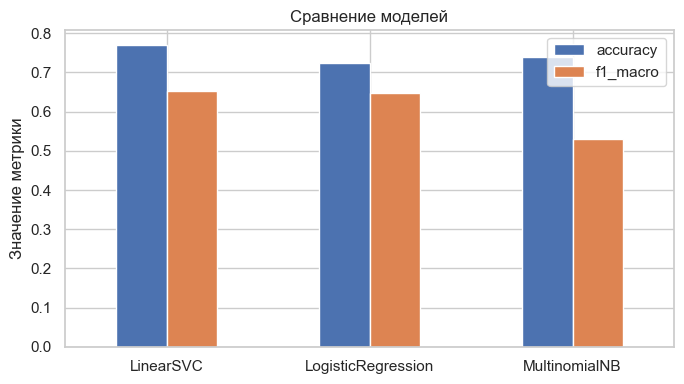

🏆 Лучшая модель по F1-macro: LinearSVC


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df[['accuracy', 'f1_macro']].plot(kind='bar', ax=ax)
ax.set_title('Сравнение моделей')
ax.set_ylabel('Значение метрики')
ax.set_xticklabels(results_df.index, rotation=0)
plt.tight_layout()
plt.show()

best_model_name = results_df['f1_macro'].idxmax()
best_model = best_estimators[best_model_name]
print(f"🏆 Лучшая модель по F1-macro: {best_model_name}")

## Детальный отчёт и матрица ошибок для лучшей модели

=== LinearSVC ===
Accuracy: 0.7689

Classification Report:
              precision    recall  f1-score   support

         Bad       0.64      0.74      0.68      3961
     Neutral       0.47      0.34      0.40      4936
        Good       0.86      0.90      0.88     17418

    accuracy                           0.77     26315
   macro avg       0.66      0.66      0.65     26315
weighted avg       0.75      0.77      0.76     26315



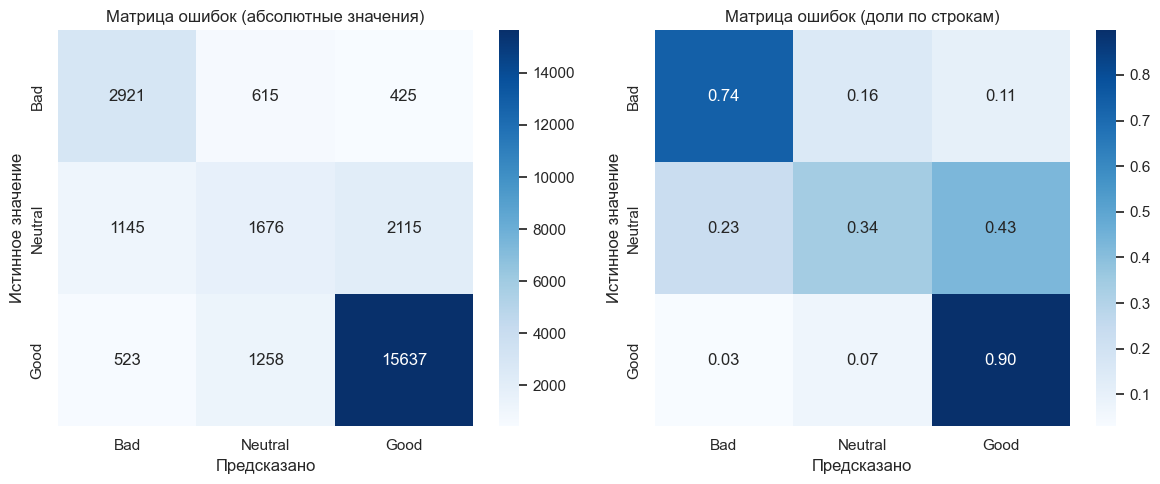

In [16]:
y_pred = best_model.predict(X_test)

print(f"=== {best_model_name} ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad', 'Neutral', 'Good']))

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad', 'Neutral', 'Good'],
            yticklabels=['Bad', 'Neutral', 'Good'], ax=axes[0])
axes[0].set_title('Матрица ошибок (абсолютные значения)')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истинное значение')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Bad', 'Neutral', 'Good'],
            yticklabels=['Bad', 'Neutral', 'Good'], ax=axes[1])
axes[1].set_title('Матрица ошибок (доли по строкам)')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истинное значение')

plt.tight_layout()
plt.show()


In [18]:
import joblib

os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_model, 'artifacts/sentiment_model.joblib')
joblib.dump(tfidf, 'artifacts/tfidf_vectorizer.joblib')

print("💾 Модель и векторизатор сохранены в папку artifacts/")


💾 Модель и векторизатор сохранены в папку artifacts/


## Предсказание с вероятностями

In [21]:
def predict_sentiment(text, model=best_model, vectorizer=tfidf, verbose=True):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    pred = model.predict(vectorized)[0]
    label = label_map_rev[pred]

    emoji = {'Bad': '😡', 'Neutral': '😐', 'Good': '😊'}[label]

    proba_str = ""
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(vectorized)[0]
        proba_str = " | ".join(
            f"{label_map_rev[i]}: {p:.2f}" for i, p in enumerate(proba)
        )
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(vectorized)[0]
        proba_str = " | ".join(
            f"{label_map_rev[i]}: {s:.2f}" for i, s in enumerate(scores)
        )

    if verbose:
        print(f"📝 {text}")
        print(f"🎯 Тональность: {label} {emoji}")
        if proba_str:
            print(f"   ({proba_str})")
        print()

    return label


test_reviews = [
    "Фильм полный бред, зря потратил время",
    "Шедевр! Обязательно посмотрю ещё раз",
    "Неплохо, но могло быть и лучше",
    "Я в полном восторге, лучший фильм года",
    "Скучно, ничего интересного",
    "Смотрится нормально, но ничего выдающегося",
    "Ужасная игра актёров и провальный сценарий",
]

print("=== ТЕСТИРОВАНИЕ МОДЕЛИ ===\n")
for review in test_reviews:
    predict_sentiment(review)


=== ТЕСТИРОВАНИЕ МОДЕЛИ ===

📝 Фильм полный бред, зря потратил время
🎯 Тональность: Bad 😡
   (Bad: 0.96 | Neutral: -0.82 | Good: -1.05)

📝 Шедевр! Обязательно посмотрю ещё раз
🎯 Тональность: Good 😊
   (Bad: -1.06 | Neutral: -0.94 | Good: 0.71)

📝 Неплохо, но могло быть и лучше
🎯 Тональность: Neutral 😐
   (Bad: -0.89 | Neutral: 1.03 | Good: -0.98)

📝 Я в полном восторге, лучший фильм года
🎯 Тональность: Good 😊
   (Bad: -0.76 | Neutral: -0.49 | Good: 0.29)

📝 Скучно, ничего интересного
🎯 Тональность: Bad 😡
   (Bad: 1.01 | Neutral: 0.19 | Good: -1.58)

📝 Смотрится нормально, но ничего выдающегося
🎯 Тональность: Neutral 😐
   (Bad: -0.65 | Neutral: 0.72 | Good: -0.86)

📝 Ужасная игра актёров и провальный сценарий
🎯 Тональность: Bad 😡
   (Bad: 1.66 | Neutral: -0.57 | Good: -1.49)

